# Meu Data Set de treinos 🏋🏻‍♂️
**Inicio do primeiro registro de treino 🚶🏻‍♂️‍➡️:**     
    *13 Mar 2023, 14:52*<br>
**Atual treino 🏃🏻‍♂️‍➡️:**    
    *30 Abr 2026, 21:27*<br>

In [18]:
import pandas as pd

## Investigando a base de dados

### Abaixo podemos ver algumas informações da nossa base de dados.

##### Colunas presentes no Data set

In [19]:
arquivo = 'workout_data.csv'
data = pd.read_csv(arquivo)
print("Nome das colunas:")
print(data.columns.tolist())



Nome das colunas:
['title', 'start_time', 'end_time', 'description', 'exercise_title', 'superset_id', 'exercise_notes', 'set_index', 'set_type', 'weight_kg', 'reps', 'distance_km', 'duration_seconds', 'rpe']


##### Estatística dos dados

In [20]:
print("Descrição estatística dos dados:")
print(data.describe())

Descrição estatística dos dados:
       description  superset_id     set_index     weight_kg          reps  \
count          0.0          0.0  14291.000000  13812.000000  13955.000000   
mean           NaN          NaN      1.983766     81.495590      7.637263   
std            NaN          NaN      1.730681     58.792114      5.139880   
min            NaN          NaN      0.000000      1.000000      1.000000   
25%            NaN          NaN      1.000000     32.000000      4.000000   
50%            NaN          NaN      2.000000     70.000000      8.000000   
75%            NaN          NaN      3.000000    110.000000     10.000000   
max            NaN          NaN     11.000000    470.000000     43.000000   

       distance_km  duration_seconds  rpe  
count    27.000000        309.000000  0.0  
mean      0.039259        392.326861  NaN  
std       0.003849        654.701404  NaN  
min       0.020000          1.000000  NaN  
25%       0.040000         38.000000  NaN  
50%      

##### Informações dos dados

In [21]:
print("Informações sobre os dados:")
print(data.info())


Informações sobre os dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             14291 non-null  object 
 1   start_time        14291 non-null  object 
 2   end_time          14291 non-null  object 
 3   description       0 non-null      float64
 4   exercise_title    14291 non-null  object 
 5   superset_id       0 non-null      float64
 6   exercise_notes    668 non-null    object 
 7   set_index         14291 non-null  int64  
 8   set_type          14291 non-null  object 
 9   weight_kg         13812 non-null  float64
 10  reps              13955 non-null  float64
 11  distance_km       27 non-null     float64
 12  duration_seconds  309 non-null    float64
 13  rpe               0 non-null      float64
dtypes: float64(7), int64(1), object(6)
memory usage: 1.5+ MB
None


##### Contagem de series por cada exercício

In [22]:
print("Contagem de series de cada exercício:")
print(data['exercise_title'].value_counts())

Contagem de series de cada exercício:
exercise_title
Supino (Barra)                   1984
Agachamento (Barra)              1497
Levantamento Terra (Barra)       1408
Elevação Lateral (Halter)         744
Rosca Direta na Barra W           638
                                 ... 
Puxada Unilateral                   3
Remadas Iso-Lateral (Máquina)       3
Encolhimento (Halter)               3
Rosca Scott (Barra)                 3
Pec Deck                            3
Name: count, Length: 72, dtype: int64


---

##### Maior carga em KG de um exercicío.
**470kg**<br>
EXERCICÍO: Leg Press 

In [23]:
print(data['weight_kg'].max())


470.0


---

##### Criando coluna de volume de serie
coluna apenas disponivel no data set do notebook, não foi transportado para o arquivo .csv

In [24]:
data['volume_serie'] = data['weight_kg'] * data['reps']
print(data.columns.tolist())

['title', 'start_time', 'end_time', 'description', 'exercise_title', 'superset_id', 'exercise_notes', 'set_index', 'set_type', 'weight_kg', 'reps', 'distance_km', 'duration_seconds', 'rpe', 'volume_serie']


---

## Criando um Identificador para Cada Exercício
Para ter uma melhor consulta dos dados, e pesquisa, vamos criar um id para cada exercício.<br>
Vamos evitar casos como:<br>
    EXEMPLO:<br>
    `Em uma pesquisa de Top 10 erxercíco com maior volume de Série, retornar apenas leg press. Vamos pegar a melhor marca do exercício e vamos seguir para o próximo.`

In [25]:
print(data['exercise_title'].value_counts())

exercise_title
Supino (Barra)                   1984
Agachamento (Barra)              1497
Levantamento Terra (Barra)       1408
Elevação Lateral (Halter)         744
Rosca Direta na Barra W           638
                                 ... 
Puxada Unilateral                   3
Remadas Iso-Lateral (Máquina)       3
Encolhimento (Halter)               3
Rosca Scott (Barra)                 3
Pec Deck                            3
Name: count, Length: 72, dtype: int64


In [26]:
data['id_exercise'] = data['exercise_title'].astype('category').cat.codes  # Criamos o ID!

# print(data['exercise_title'][data['id_exercise'] == 2])
# ===============  OUUU ========================
print(data.loc[data['id_exercise'] == 35, 'exercise_title']) 

# ACIMA ESTAMOS PRINTANDO O EXERCÍCIO BASEADO EM SEU ID!

106      Levantamento Terra (Barra)
107      Levantamento Terra (Barra)
108      Levantamento Terra (Barra)
109      Levantamento Terra (Barra)
110      Levantamento Terra (Barra)
                    ...            
14286    Levantamento Terra (Barra)
14287    Levantamento Terra (Barra)
14288    Levantamento Terra (Barra)
14289    Levantamento Terra (Barra)
14290    Levantamento Terra (Barra)
Name: exercise_title, Length: 1408, dtype: object


---

## Tabela auxiliar

Como vai ser feita mais de uma pesquisa do tipo: `top 10 maiores cargas por exercicío`, pensando em um cénario de BIG DATA, não é nada eficiente para cada pesquisa ficar procurando em 14 mil linhas de dados. Pensando neste problema o mais eficiente é criar uma **tabela auxiliar**, o que seria essa tabela?<br>
Vai ser uma tabela onde vai ser guardado: 
- Nome do exercicío;
- ID;
- maior carga;
- maior volume;

In [27]:
tabela_auxiliar = data.groupby(by = 'id_exercise').agg({"exercise_title":"first","weight_kg": "max", "reps": "max", "volume_serie": "max",})
print(tabela_auxiliar)



                                                exercise_title  weight_kg  \
id_exercise                                                                 
0                                         Abdominal Na Máquina       85.0   
1                                        Abdominal Tradicional        NaN   
2            Aberturas Invertidas De Ombro Posterior (Na Má...      105.0   
3                                          Agachamento (Barra)      240.0   
4                                          Agachamento Búlgaro      100.0   
...                                                        ...        ...   
67                                      Supino No Chão (Barra)      140.0   
68                                       Triceps Testa (Barra)       45.0   
69                              Tríceps na Paralela (Com Peso)       24.0   
70                                            Tríceps na Polia       47.0   
71                                  Tríceps na Polia com Corda       40.0   

---

### Gráfico de top 5 maior volume de serie

In [28]:

import matplotlib.pyplot as plt

In [29]:
top10 = tabela_auxiliar.nlargest(10, 'volume_serie')
print(top10)

                                               exercise_title  weight_kg  \
id_exercise                                                                
32                                    Leg Press 45º (Máquina)      470.0   
20                                   Elevação Pélvica (Barra)      240.0   
11                                Cadeira Extensora (Máquina)      132.5   
21           Elevação Unilateral de Panturrilha em Pé (Barra)      240.0   
35                                 Levantamento Terra (Barra)      275.0   
22                      Elevação de Panturrilha em Pé (Barra)      200.0   
40                               Panturrilha no Leg Press 45º      300.0   
4                                         Agachamento Búlgaro      100.0   
52                   Remada (Corda) Sentado - Pegas Afastadas      127.0   
53                                            Remada (Halter)       82.0   

             reps  volume_serie  
id_exercise                      
32           20.0  

In [43]:
y = top10['volume_serie']
x = top10['exercise_title']
print(x)

id_exercise
32                             Leg Press 45º (Máquina)
20                            Elevação Pélvica (Barra)
11                         Cadeira Extensora (Máquina)
21    Elevação Unilateral de Panturrilha em Pé (Barra)
35                          Levantamento Terra (Barra)
22               Elevação de Panturrilha em Pé (Barra)
40                        Panturrilha no Leg Press 45º
4                                  Agachamento Búlgaro
52            Remada (Corda) Sentado - Pegas Afastadas
53                                     Remada (Halter)
Name: exercise_title, dtype: object


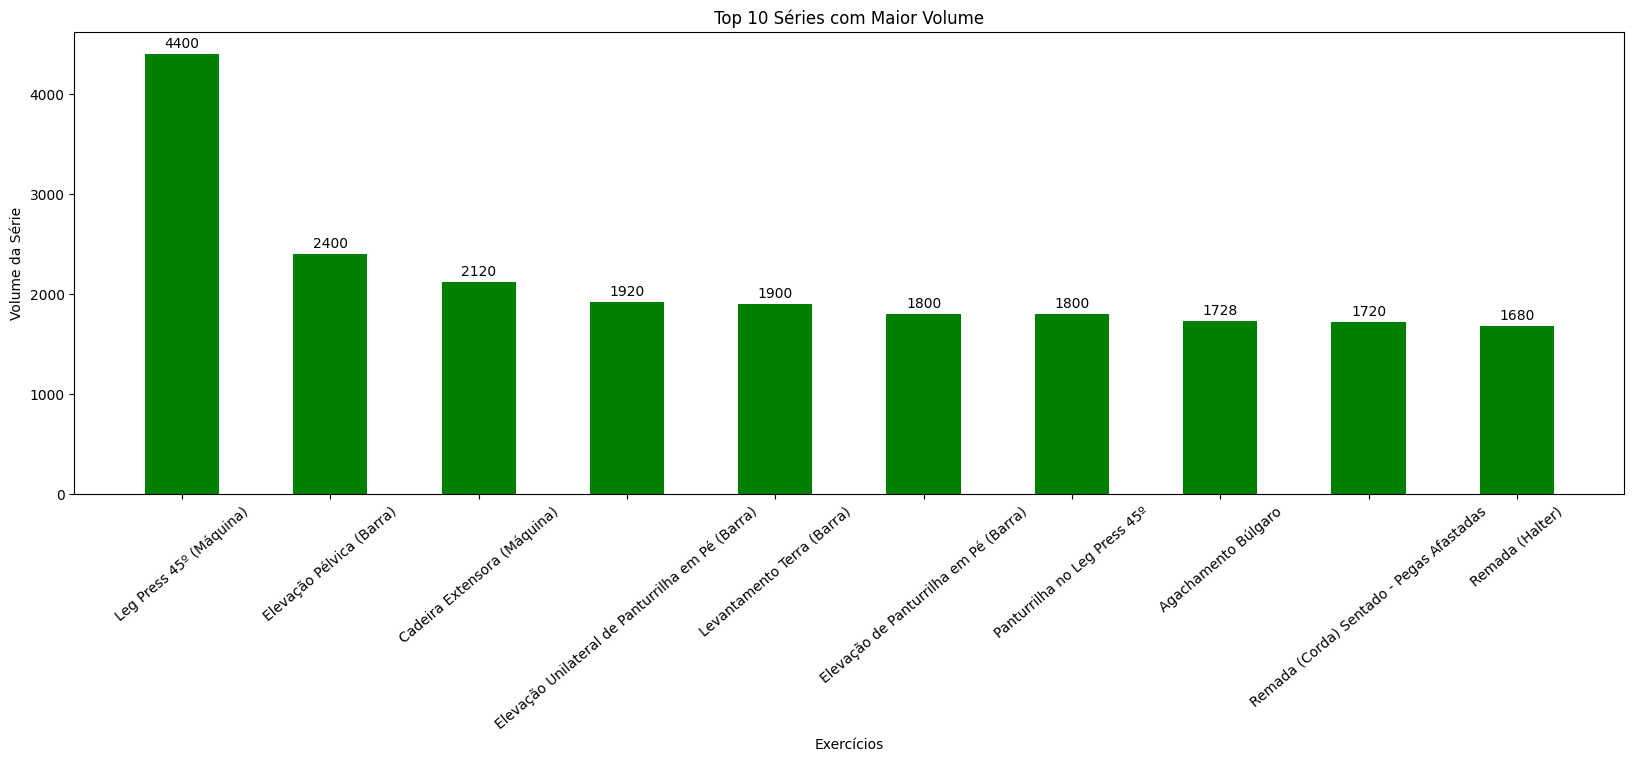

In [44]:
fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.bar(x, y, color='green', width=0.5)
ax.bar_label(meugrafico, padding=3)
ax.set_xlabel('Exercícios')
ax.set_ylabel('Volume da Série')
ax.set_title('Top 10 Séries com Maior Volume')
plt.xticks(rotation=40)
plt.show()

#### Conclusão
Após ser criado nossa tabela auxliar, para otimizar nossa consulta e resultados, chegamos aos resultados acima. Os exercicíos que se destacam em volume de série são exercicíos para grupos musculares inferiores, como pernas e gluteos, pois por se tratar de um grupo muscular maior, se destaca em carga e repetições!!

---

## Top 10 exercicio com melhores cargas de serie

In [32]:
top10_kg = tabela_auxiliar.nlargest(10, 'weight_kg')
print(top10_kg['weight_kg'])

id_exercise
32    470.0
40    300.0
35    275.0
3     240.0
20    240.0
21    240.0
36    235.0
5     230.0
22    200.0
34    200.0
Name: weight_kg, dtype: float64


In [33]:
y = top10_kg['weight_kg']
x = top10_kg['exercise_title']
print(x)

id_exercise
32                             Leg Press 45º (Máquina)
40                        Panturrilha no Leg Press 45º
35                          Levantamento Terra (Barra)
3                                  Agachamento (Barra)
20                            Elevação Pélvica (Barra)
21    Elevação Unilateral de Panturrilha em Pé (Barra)
36                             Levantamento Terra Sumô
5                        Agachamento com Banco (Barra)
22               Elevação de Panturrilha em Pé (Barra)
34                Levantamento Terra (Barra Hexagonal)
Name: exercise_title, dtype: object


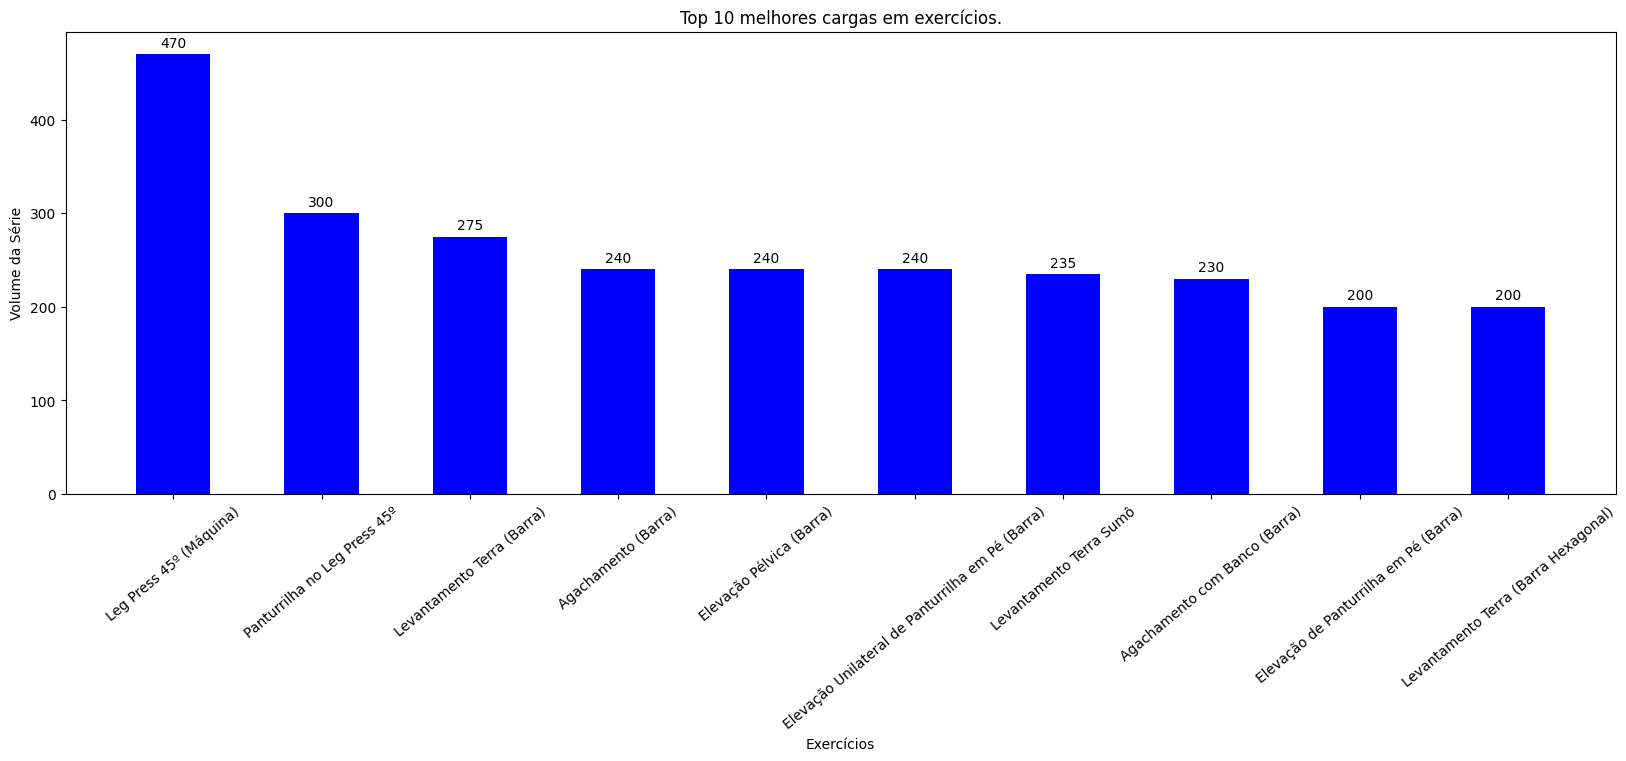

In [41]:
fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.bar(x, y, color='blue', width=0.5)
ax.bar_label(meugrafico, padding=3)
ax.set_xlabel('Exercícios')
ax.set_ylabel('Volume da Série')
ax.set_title('Top 10 melhores cargas em exercícios.')
plt.xticks(rotation=40)
plt.show()

## Conclusão
Podemos notar que nosso campeão de carga é o **Leg pres 45°**, em seguida se segue mais exercicío de membros inferiores.<br>
Podemos notar que a carga de 240kg se repetem com frêquencia, embora na elevação pelvica não tenha sido testado mais uma repetição máxima!

---

## Evolução nos exercícios principais
* Agachamento (Squat)
* Supino (Bench)
* Levantamento terra (Deadlift)

Podemos notar que em nosso Data set as datas não vem em formato de data, logo, para que seja possível ver a evolução de um exercicío em questão do tempo, precisamos ajustar isto primeiro!<br>
Na celula abaixo iremos traduzir os meses, de português para Inglês.

In [52]:
traducao_meses = {
    'Abr': 'Apr', 'Mai': 'May', 'Ago': 'Aug', 
    'Set': 'Sep', 'Out': 'Oct', 'Dez': 'Dec', 'Fev': 'Feb'
}

data['start_time'] = data['start_time'].replace(traducao_meses, regex=True)

In [53]:
print(data['start_time'])
print("="*50)
print(data['start_time'].info)

0        30 Apr 2026, 19:37
1        30 Apr 2026, 19:37
2        30 Apr 2026, 19:37
3        30 Apr 2026, 19:37
4        30 Apr 2026, 19:37
                ...        
14286    13 Mar 2023, 14:52
14287    13 Mar 2023, 14:52
14288    13 Mar 2023, 14:52
14289    13 Mar 2023, 14:52
14290    13 Mar 2023, 14:52
Name: start_time, Length: 14291, dtype: object
<bound method Series.info of 0        30 Apr 2026, 19:37
1        30 Apr 2026, 19:37
2        30 Apr 2026, 19:37
3        30 Apr 2026, 19:37
4        30 Apr 2026, 19:37
                ...        
14286    13 Mar 2023, 14:52
14287    13 Mar 2023, 14:52
14288    13 Mar 2023, 14:52
14289    13 Mar 2023, 14:52
14290    13 Mar 2023, 14:52
Name: start_time, Length: 14291, dtype: object>


In [55]:
data['start_time'] = pd.to_datetime(data['start_time'], format="%d %b %Y, %H:%M")

print(data['start_time'].head())
print("="*50)
print(data['start_time'])
print("="*50)
print(data['start_time'].info)


0   2026-04-30 19:37:00
1   2026-04-30 19:37:00
2   2026-04-30 19:37:00
3   2026-04-30 19:37:00
4   2026-04-30 19:37:00
Name: start_time, dtype: datetime64[ns]
0       2026-04-30 19:37:00
1       2026-04-30 19:37:00
2       2026-04-30 19:37:00
3       2026-04-30 19:37:00
4       2026-04-30 19:37:00
                ...        
14286   2023-03-13 14:52:00
14287   2023-03-13 14:52:00
14288   2023-03-13 14:52:00
14289   2023-03-13 14:52:00
14290   2023-03-13 14:52:00
Name: start_time, Length: 14291, dtype: datetime64[ns]
<bound method Series.info of 0       2026-04-30 19:37:00
1       2026-04-30 19:37:00
2       2026-04-30 19:37:00
3       2026-04-30 19:37:00
4       2026-04-30 19:37:00
                ...        
14286   2023-03-13 14:52:00
14287   2023-03-13 14:52:00
14288   2023-03-13 14:52:00
14289   2023-03-13 14:52:00
14290   2023-03-13 14:52:00
Name: start_time, Length: 14291, dtype: datetime64[ns]>


In [75]:
tabela_auxiliar_carga = data.groupby(by = ['start_time', 'id_exercise']).agg({"exercise_title":"first","weight_kg": "max",}).reset_index()
print(tabela_auxiliar_carga)



              start_time  id_exercise  \
0    2023-03-13 14:52:00           35   
1    2023-03-14 14:47:00            6   
2    2023-03-14 14:47:00           41   
3    2023-03-14 14:47:00           64   
4    2023-03-15 16:22:00            3   
...                  ...          ...   
3265 2026-04-30 19:37:00           11   
3266 2026-04-30 19:37:00           12   
3267 2026-04-30 19:37:00           20   
3268 2026-04-30 19:37:00           21   
3269 2026-04-30 19:37:00           32   

                                        exercise_title  weight_kg  
0                           Levantamento Terra (Barra)      140.0  
1                                         Alongamentos        NaN  
2                                             Pec Deck       45.0  
3                                       Supino (Barra)       65.0  
4                                  Agachamento (Barra)      115.0  
...                                                ...        ...  
3265                       Cade

In [ ]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 35, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 35, 'weight_kg']
print(y)


0       140.0
20      140.0
41      120.0
51      130.0
61      110.0
        ...  
3178    245.0
3193    250.0
3222    275.0
3234    240.0
3249    250.0
Name: weight_kg, Length: 244, dtype: float64


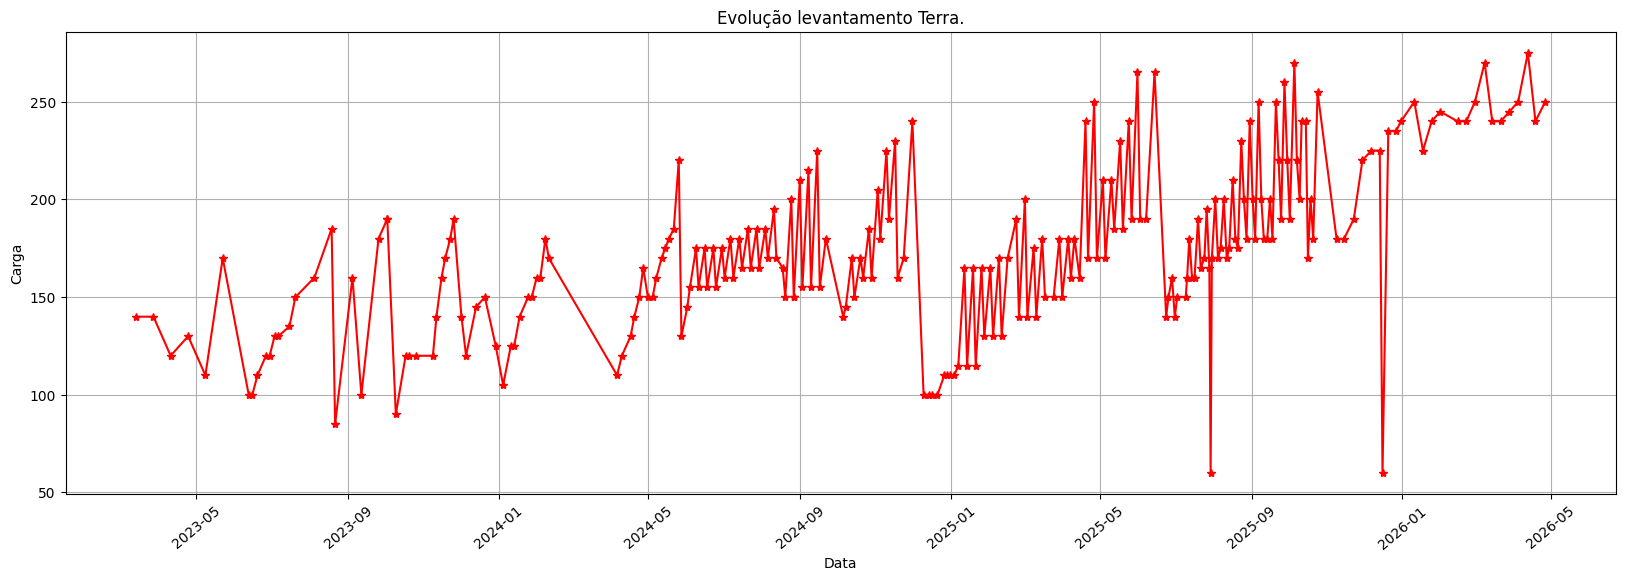

In [77]:
fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='red', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução levantamento Terra.')
plt.xticks(rotation=40)
plt.show()

In [90]:
# print(tabela_auxiliar_carga.loc[tabela_auxiliar_carga['exercise_title'] == 'Agachamento (Barra)', 'id_exercise']) 
# print(tabela_auxiliar_carga.loc[tabela_auxiliar_carga['exercise_title'] == 'Supino (Barra)', 'id_exercise']) 


# print(tabela_auxiliar_carga.loc[tabela_auxiliar_carga['exercise_title'] == 'Agachamento Búlgaro', 'id_exercise']) 

print(tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 20, 'exercise_title']) 


98      Elevação Pélvica (Barra)
144     Elevação Pélvica (Barra)
170     Elevação Pélvica (Barra)
208     Elevação Pélvica (Barra)
256     Elevação Pélvica (Barra)
                  ...           
3090    Elevação Pélvica (Barra)
3120    Elevação Pélvica (Barra)
3168    Elevação Pélvica (Barra)
3211    Elevação Pélvica (Barra)
3267    Elevação Pélvica (Barra)
Name: exercise_title, Length: 101, dtype: object


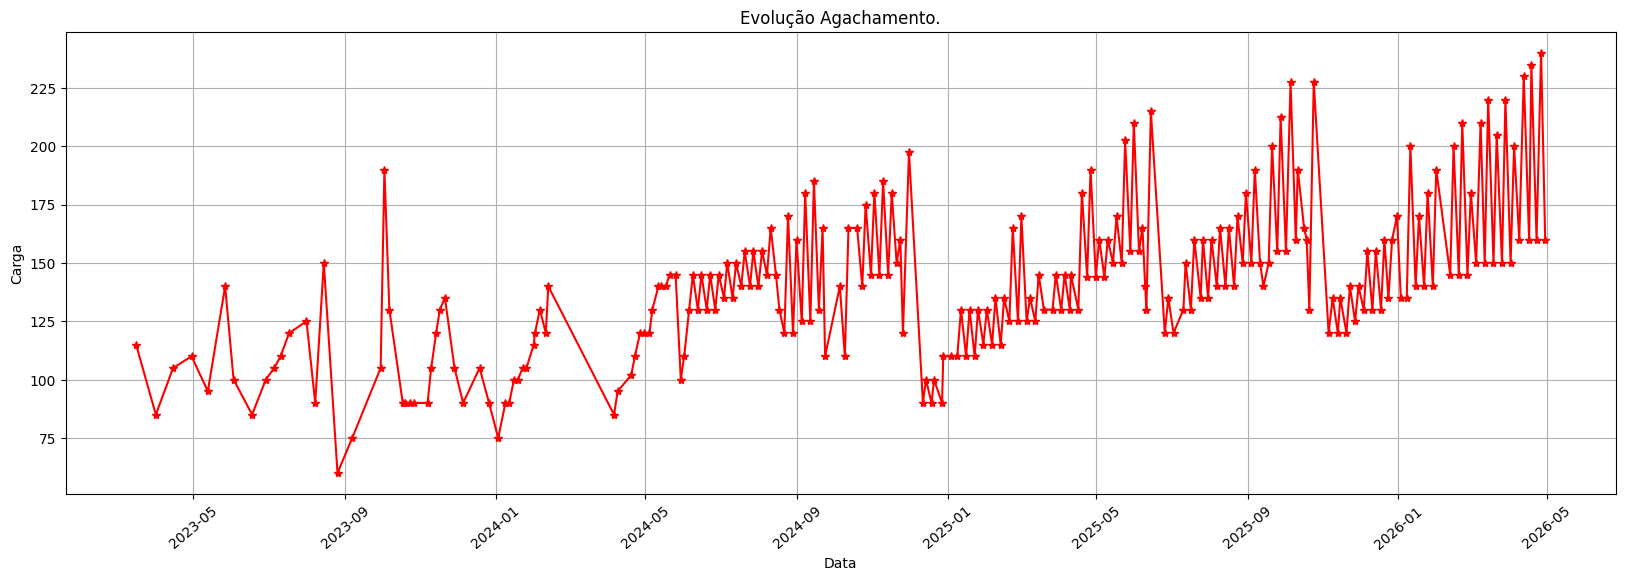

In [79]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 3, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 3, 'weight_kg']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='red', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução Agachamento.')
plt.xticks(rotation=40)
plt.show()

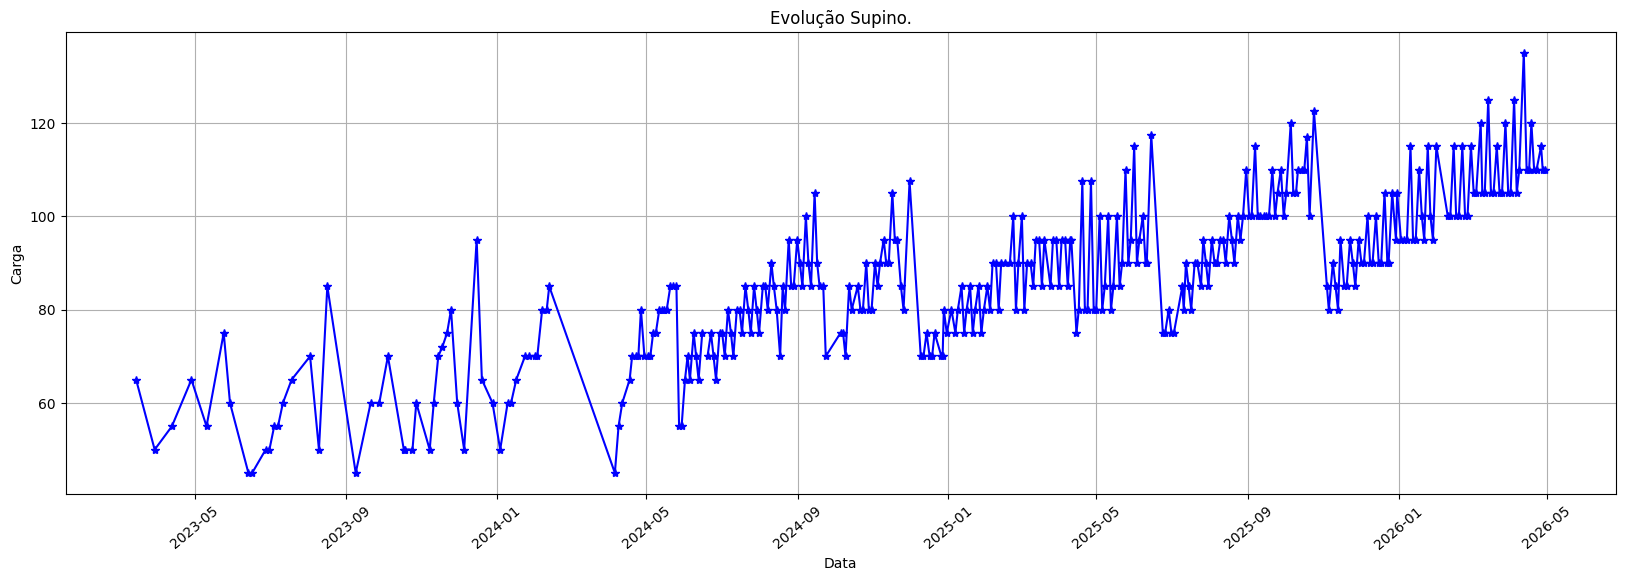

In [81]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 64, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 64, 'weight_kg']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='blue', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução Supino.')
plt.xticks(rotation=40)
plt.show()

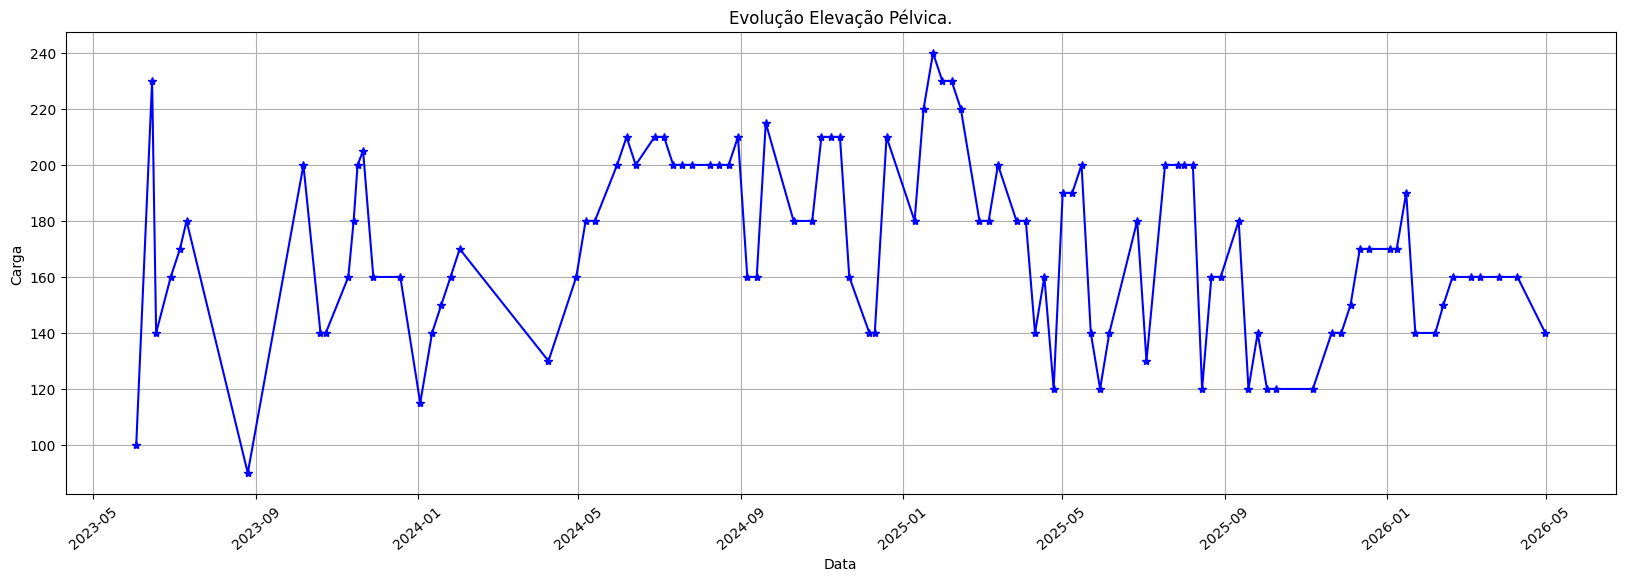

In [92]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 20, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 20, 'weight_kg']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='blue', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução Elevação Pélvica.')
plt.xticks(rotation=40)
plt.show()